In [70]:
# importation de modules
import copy
import numpy as np
from sympy import symbols, latex
import project_utils as utils
from matplotlib import pyplot as plt

<h2 style="font-family: Arial;">1 - Définition des Classes et Fonctions nécessaires</h2>

<h3 style="font-family: Arial;">1.1 - Classe <span style="color: #1d4ed8;">P</span> représentant un polynôme</h3>

In [71]:
class P:
    """
    > Cette class est une représentation d'un polynôme quelconque donné
        - Elle prend en arguments les coefficents (a0, a1, ..., aN)
    """
    def __init__(self, coefs: np.ndarray|tuple|list, name = "P"):
        self.name = name                                          # nom du polynôme
        self.coefs = np.array(coefs, dtype=np.float64).ravel()    # suppression d'ordre ligne-colonne et affectation des coefficients
        self.degree = self.coefs.shape[0] - 1                     # détermination du degré du polynôme
        

    def __repr__(self):
        """ Cette fonction crée une représentation du polynôme """
        #if self.degree == 1:
        #    return f"{self.name}(x) = {self.coefs[0]}"
        
        chain = f"{self.name}(X) = "
        terms = []
        for index, value in enumerate(self.coefs):
            if value == 0:
                continue
            coef = str(value) # int(value) if int(value) == value else value
            if index == 0:
                terms.append(coef)
            elif index == 1:
                terms.append(f"{'' if value == 1 else '-' if value == -1 else coef}X")
            else:
                terms.append(f"{'' if value == 1 else '-' if value == -1 else coef}X^{index}")
        return chain + ' + '.join(terms).replace('+ -', '- ')
    

    def __str__(self):
        """ Cette fonction crée une représentation du polynôme pour 'print' """
        return self.__repr__()
    

    def beautiful_display(self):
        """ Cette fonction affiche le polynome avec Sympy """
        x = symbols('x')
        polynome = sum(c * x**i for i, c in enumerate(self.coefs))
        latex_expr = latex(polynome)

        # Générer l'expression LaTeX
        latex_expr = f"{self.name}(x) = " + latex(polynome)

        # Afficher le polynôme en LaTeX
        display(utils.Math(latex_expr))


    def derivate(self, name = "Q"):
        """ Cette fonction retourne le polynôme dérivée"""
        derivate_coefs = [(index + 1) * value for index, value in enumerate(self.coefs[1:])]
        return P(derivate_coefs, name = name)
    
    def image(self, a: float):
        """ Cette fonction calcule l'image de a par le polynôme """
        x = np.array([a**i for i in range(self.degree + 1)])
        return np.round(self.coefs @ x, 6)  # produit scalaire(matriciel 1xn . nx1 = 1x1) entre self.coefs et x


    def euclidian_polynomial_division(self, Q: 'P'):
        """
            Cette fonction réalise la division polynômiale de P par Q
            > retourne un tableau des restes et quotients
        """
        # if dividend's degree is less than divisor's then the dividend is the remainder
        if self.degree < Q.degree:
            return self.coefs.copy(), self.degree + 1
        
        dividend = self.coefs.copy()                                # creation du la dividende : les coefficeint de la classe
        divisor  = Q.coefs.copy()                                   # creation du diviseur : les coefficeint du polynôme Q
        quotients = []                                              # initialisation du quotient `a une cha^ıne vide

        for index in range(self.degree, Q.degree - 1, -1):
            quotient = dividend[index] / divisor[-1]                 # calcul du quotient
            quotients.append(quotient)                               # ajout du quotient à la liste
            current_divisor = quotient * divisor.copy()              # copie et multiplication du diviseur par le quotient
            nb_zero_left = index - Q.degree                          # nombre de zéro à gauche pour tendre vers le degré de la dividende
            nb_zero_right = self.degree - Q.degree - nb_zero_left    # nombre de zéro à gauche pour tendre vers le degré de la dividende
            # Ajout des zéros
            current_divisor = np.hstack((np.zeros(nb_zero_left), current_divisor, np.zeros(nb_zero_right)))
            dividend -= current_divisor                              # soustration et mise à jour de la dividende
        
        # la dividende contient à ce niveau les coefficients du reste de la division polynômiale
        quotients.reverse()                                          # on inverse l'ordre des coefficients du quotient (ordre croissant)
        dividend[Q.degree:] = quotients
        
        # on renvoie (liste de reste, quotient), et le nombre de coefficients du reste
        return dividend, Q.degree
    

    def get_euclidian_remainder(self, Q: 'P', name = "K"):
        """ Cette fonction cré un polynôme avec les coefficients du reste de la division de P par Q """
        poly, length = self.euclidian_polynomial_division(Q)
        return P(poly[:length], name=name)
    
    
    def oppose_sign(self):
        """ Cette fonction change le polynôme en son opposé """
        self.coefs *= -1

<h2 style="font-family: Arial;">> Instanciation de 'P' et affichage</h2>

In [82]:
# Utilisation de la classe
f = P([2, 1, 1], name="f")
g = P([0, 1, 3, 3, 1/8], name="g")

# affichage en ligne de commande
print(f)
print(g)

# affichage avec Sympy
f.beautiful_display()
g.beautiful_display()

f(X) = 2.0 + X + X^2
g(X) = X + 3.0X^2 + 3.0X^3 + 0.125X^4


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<h2 style="font-family: Arial;">> Division polynômiale : Utilisation 1</h2>

In [83]:
# Utilisation de la classe
p = P([3, 1, -2, 6], name="P")
d = P([1, -1, 1], name="D")

# affichage en ligne de commande
print(p)
p.beautiful_display()
print("----------------------")
print(d)
d.beautiful_display()
print("----------------------")

# Calcul de la division polynômiale
q_r, degre_r = p.euclidian_polynomial_division(d)

# récupération des coefficients
reste_coefs = q_r[:degre_r]
quotient_coefs = q_r[degre_r:]

# Création et affichage
q = P(quotient_coefs, name="Q")
r = P(reste_coefs, name="R")

print(q)
q.beautiful_display()
print("----------------------")
print(r)

r.beautiful_display()

P(X) = 3.0 + X - 2.0X^2 + 6.0X^3


<IPython.core.display.Math object>

----------------------
D(X) = 1.0 - X + X^2


<IPython.core.display.Math object>

----------------------
Q(X) = 4.0 + 6.0X


<IPython.core.display.Math object>

----------------------
R(X) = -1.0 - X


<IPython.core.display.Math object>

<h2 style="font-family: Arial;">> Division polynômiale : Utilisation 2</h2>

In [74]:
f = P([-3, 7, -2, 1], name="F")
g = P([-2, 1], name="G")

f.beautiful_display()
g.beautiful_display()


div_coefs, nb_r = f.euclidian_polynomial_division(g)
r = P(div_coefs[:nb_r], 'R')
q = P(div_coefs[nb_r:], 'Q')

q.beautiful_display()
r.beautiful_display()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<h2 style="font-family: Arial;">> Division polynômiale : Utilisation 3</h2>
<div  style="font-family: Arial;">Degré de la dividende = celui diviseur</div>

In [75]:
f = P([-2, 1], name="F")
g = P([-3, 7], name="G")

f.beautiful_display()
g.beautiful_display()


div_coefs, nb_r = f.euclidian_polynomial_division(g)
r = P(div_coefs[:nb_r], 'R')
q = P(div_coefs[nb_r:], 'Q')

q.beautiful_display()
r.beautiful_display()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<h2 style="font-family: Arial;">> Division polynômiale : Utilisation 4</h2>
<div  style="font-family: Arial;">Degré de la dividende plus petit celui diviseur</div>

In [76]:
f = P([-2, 1], name="F")
g = P([-3, 7, 1], name="G")

f.beautiful_display()
g.beautiful_display()


div_coefs, nb_r = f.euclidian_polynomial_division(g)
r = P(div_coefs[:nb_r], 'R')
q = P(div_coefs[nb_r:], 'Q')

q.beautiful_display()
r.beautiful_display()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<h3 style="font-family: Arial;">1.1 - Classe <span style="color: #1d4ed8;">SturmSeqeunce</span> générant une séquence de Sturm</h3>

In [77]:
class SturmSeqeunce:
    """
        Étant donné un polynôme P,Cette classe génère la séquence
        des fonctions utiles pour la méthode de Sturm
    """
    def __init__(self):
        self.num = -1         # gère les noms successifs des polynômes
        self.sequence = []    # contiendra la séquence de Sturm
    
    def incr_num(self):
        """ Guide les noms successifs des polynômes à générer """
        self.num += 1
    
    def generate_name(self):
        """ Guide le nom d'un polynôme """
        self.incr_num()                 # choix de nom
        return chr(self.num % 26 + 65)  # le nom sera entre A et Z
    

    def generate_sequence(self, M: P):
        """ Cette fonction génère la séquence de Sturm """
        M.name = self.generate_name()                          # On génère le nom pour le polynôme initial
        self.sequence.append(M)                                # Ajout du polynôme à la liste des séquences
        
        if M.degree == 0:                                      # Si son degré vaut 0, inutile de poursuive
            return
        
        N = M.derivate(name= self.generate_name())             # On calcule la dérivée du polynôme
        self.sequence.append(N)                                # Ajout de la dérivée à la liste

        while N.degree >= 1:                                   # Génération du reste des éléments de la séquence
            R = M.get_euclidian_remainder(N)                   # Reste de la division polynômiale de M par N
            R.name = self.generate_name()                      # Mise à jour du nom du reste
            R.oppose_sign()                                    # Changement de signe du reste de la division
            self.sequence.append(R)                            # Ajout à la liste
            M = N                                              # Le diviseur devient la dividende
            N = R                                              # la reste (* -1) devient le diviseur
        
    
    def number_of_solutions_on(self, a:float, b: float):
        a, b = min(a, b), max(a, b)                            # a contient le minimum de a et b, b contient le maximum
        left_pattern, right_pattern = "", ""                   # initatilisation des modèle de signes de gauche et de droite
        for f in self.sequence:
            left_pattern += "+" if f.image(a) >= 0 else "-"     # stockage des signes
            right_pattern += "+" if f.image(b) >= 0 else "-"    # stockage des signes

        return a, b, np.abs((left_pattern.count("-+") + left_pattern.count("+-")) - (right_pattern.count("-+") + right_pattern.count("+-")))
    
    
    def generate_solutions(self, set_1: list, set_2: list) -> dict:
        dico = {f"[{a}, {b}]": s for a, b, s in [self.number_of_solutions_on(a, b) for a, b in zip(set_1, set_2)]}    # generation des solutions par intervalle
        dico = dict(sorted(dico.items(), key=lambda item: len(item[0])))                                              # sorting by key length
        return dico


<h2 style="font-family: Arial;">2 - Excécution avec quelques polynômes</h2>

<h3 style="font-family: Arial;">2.1 - Le polynôme P(x) = (x² - x - 6)*(1 - x^2/2) = -x⁴/2 + x³/2 - 4x² - x -6</h3>
<div style="font-family: Arial; border-left: 10px #4338ca solid; font-size: 1.3em; padding-left: 10px;">
    Ce polynôme possède deux solutions x = -2, x = -&#x221A;2, x = &#x221A;2 et x = 3 tous sur [-3, 3] <br/>
    Représentation graphique aur [-3, 4]
</div>

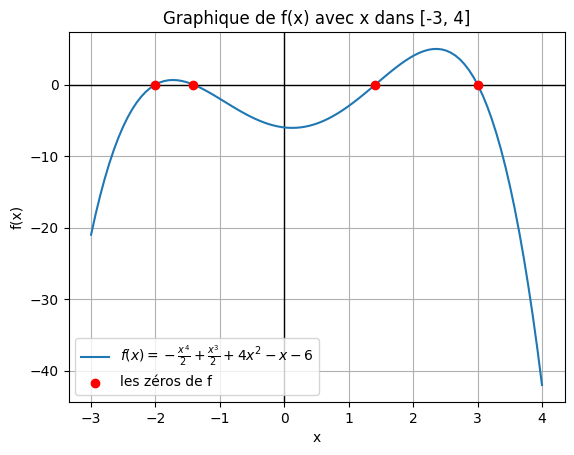

In [78]:
def f(x):
    return (x**2 -x - 6) * (1 - x**2/2)

x = np.linspace(-3, 4, 100)
y = f(x)

plt.grid(True)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.title('Graphique de f(x) avec x dans [-3, 4]')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.plot(x, y, label=r'$f(x) = -\frac{x^4}{2} + \frac{x^3}{2} + 4x^2 - x - 6$')
plt.scatter([-2, -np.sqrt(2), np.sqrt(2), 3], [0, 0, 0, 0], c="red", zorder=2, label="les zéros de f")
plt.legend()
plt.show()

<h3 style="font-family: Arial;">2.2 - Pratique avec Sturm</h3>

In [79]:
# instanciation du polynôme
Q = P([-6, -1, 4, 1/2, -1/2], name="Q")
print(Q.image(np.sqrt(2)))

# instance de la classe SturmSeqeunce et génération des fonsctions de la séquence
s = SturmSeqeunce()
s.generate_sequence(Q)


########################################### EXECUTION 1 : Valeurs choisies
# création des bornes des sous-intevalles
left_set = [-4, -2, -1, 1, 2, -1.5, -2, -2, 3, -100]   # bornes de gauche
right_set = [-2.1, -1, 1, 2, 3, 2, 2, 3, 4, 100]       # bornes de droite
solutions = s.generate_solutions(left_set, right_set)

print(">>> VÉRIFICATION DES RÉSULTATS SUR LES SOUS-INTERVALLES CHOISIS")

# compute as html
html_text = utils.compute_as_html_table(solutions)
# display
utils.display_as_html(html_text)

0.0
>>> VÉRIFICATION DES RÉSULTATS SUR LES SOUS-INTERVALLES CHOISIS


Interval,Number of solutions
"[1, 2]",1
"[2, 3]",0
"[3, 4]",1
"[-1, 1]",0
"[-2, 2]",2
"[-2, 3]",2
"[-2, -1]",1
"[-1.5, 2]",2
"[-4, -2.1]",0
"[-100, 100]",4


<h3 style="font-family: Arial;">2.3 - Pratique avec Sturm avec des valeurs choisies aléatoirement</h3>

In [80]:
# Génération des valeurs
N = 10
MIN, MAX = -20, 50
left_set = [np.random.randint(MIN, MAX) for _ in range(N)]
right_set = [np.random.randint(MIN, MAX) for _ in range(N)]
solutions = s.generate_solutions(left_set, right_set)

print(">>> VÉRIFICATION DES RÉSULTATS SUR LES SOUS-INTERVALLES CHOISIS AU HASARD")

# compute as html
html_text = utils.compute_as_html_table(solutions)
# display
utils.display_as_html(html_text)

>>> VÉRIFICATION DES RÉSULTATS SUR LES SOUS-INTERVALLES CHOISIS AU HASARD


Interval,Number of solutions
"[0, 25]",2
"[4, 41]",0
"[49, 49]",0
"[13, 46]",0
"[24, 32]",0
"[-8, -1]",2
"[-11, 22]",4
"[-16, 47]",4
"[-11, 31]",4
"[-20, -10]",0


In [86]:
p = P([1, -2, 1])
p.beautiful_display()

s = SturmSeqeunce()
s.generate_sequence(p)

s.sequence

<IPython.core.display.Math object>

[A(X) = 1.0 - 2.0X + X^2, B(X) = -2.0 + 2.0X, C(X) = ]

In [87]:
solutions = s.generate_solutions([0], [2])

print(">>> VÉRIFICATION DES RÉSULTATS SUR LES SOUS-INTERVALLES CHOISIS")

# compute as html
html_text = utils.compute_as_html_table(solutions)
# display
utils.display_as_html(html_text)

>>> VÉRIFICATION DES RÉSULTATS SUR LES SOUS-INTERVALLES CHOISIS


Interval,Number of solutions
"[0, 2]",2
